### **TUGAS 1**    
### **SISTEM LINEAR DAN METODE ELIMINASI GAUSSIAN**

**ELIMINASI GAUSSIAN**   
    Eliminasi gauss ditemukan oleh Carl Friedrich Gauss, metode ini dapat dimanfaatkan untuk memecahkan sistem persamaan linear dengan merepresentasikan (mengubah) menjadi bentuk matriks, matriks tersebut lalu diubah kebentuk Eselon Baris melalui Operasi Baris Elementer. Kemudian sistem diselesaikan dengan substitusi balik.   
    


CONTOH    
Selesaikan persamaan berikut ini dengan metode Eliminasi Gaussian

\begin{bmatrix}
 8x_1+9x_2+x_3&=&19\\
x_1+2x_2+3x_3&=&9\\
2x_1+x_2+x_3&=&5\\ \end{bmatrix}




yang pertama deklarasikan RowSwap, RowAdd dan RowScale untuk perhitungan selanjutnya

In [1]:
import numpy as np

def RowSwap(A,k,l):
    m = A.shape[0]
    n = A.shape[1]

    B = np.copy(A).astype('float64')

    for j in range(n):
        temp = B[k][j]
        B[k][j] = B[l][j]
        B[l][j] = temp

    return B

def RowScale(A,k,scale):
    m = A.shape[0]
    n = A.shape[1]

    B = np.copy(A).astype('float64')

    for j in range(n):
        B[k][j] *= scale

    return B

def RowAdd(A,k,l,scale):
    m = A.shape[0]
    n = A.shape[1]

    B = np.copy(A).astype('float64')

    for j in range(n):
        B[l][j] += B[k][j]*scale

    return B

buat array NumPy dengan nilai-nilai ini. Kita akan memberi nama pada array A, sehingga kita bisa memanggilnya lagi nanti.

In [ ]:
import numpy as np
A=np.array([[8,9,1,19],[1,2,3,9],[2,1,1,5]])
print(A)

[[ 8  9  1 19]
 [ 1  2  3  9]
 [ 2  1  1  5]]


In [ ]:
#pindahkan baris 0 ke baris 1
A1 = RowSwap(A, 0, 1)
print(A1)

[[ 1.  2.  3.  9.]
 [ 8.  9.  1. 19.]
 [ 2.  1.  1.  5.]]


In [ ]:
#tambahkan -8 kali baris 0 ke baris 1
A2 = RowAdd(A1, 0, 1, -8)
print(A2)

[[  1.   2.   3.   9.]
 [  0.  -7. -23. -53.]
 [  2.   1.   1.   5.]]


In [ ]:
#tambahkan -2 kali baris 0 ke baris 2
A3 = RowAdd(A2, 0, 2, -2)
print(A3)

[[  1.   2.   3.   9.]
 [  0.  -7. -23. -53.]
 [  0.  -3.  -5. -13.]]


In [ ]:
#kalikan baris 1 dengan -1/7
A4 = RowScale(A3, 1, -1/7)
print(A4)

[[  1.           2.           3.           9.        ]
 [ -0.           1.           3.28571429   7.57142857]
 [  0.          -3.          -5.         -13.        ]]


In [ ]:
#tambahkan 3 kali baris 1 ke baris 2
A5 = RowAdd(A4, 1, 2, 3)
print(A5)

[[ 1.          2.          3.          9.        ]
 [-0.          1.          3.28571429  7.57142857]
 [ 0.          0.          4.85714286  9.71428571]]


In [ ]:
#kalikan baris 2 dengan 1/4
A6 = RowScale(A5, 2, 1/4)
print(A6)

[[ 1.          2.          3.          9.        ]
 [-0.          1.          3.28571429  7.57142857]
 [ 0.          0.          1.21428571  2.42857143]]


#cara 2

In [ ]:
import numpy as np

# Matriks koefisien
A = np.array([[8, 9, 1],
              [1, 2, 3],
              [2, 1, 1]], dtype=float)

# Matriks hasil
b = np.array([19, 9, 5], dtype=float)

# Gabungkan matriks A dan b menjadi augmented matrix
augmented_matrix = np.column_stack((A, b))

# Eliminasi Gauss
n = len(augmented_matrix)
for i in range(n):
    # Pilih elemen utama
    pivot_row = i
    for j in range(i+1, n):
        if abs(augmented_matrix[j, i]) > abs(augmented_matrix[pivot_row, i]):
            pivot_row = j
    augmented_matrix[[i, pivot_row]] = augmented_matrix[[pivot_row, i]]

    # Lakukan eliminasi
    for j in range(i+1, n):
        factor = augmented_matrix[j, i] / augmented_matrix[i, i]
        augmented_matrix[j] -= factor * augmented_matrix[i]

# Cek apakah matriks koefisien memenuhi kriteria eliminasi Gauss
is_full_rank = np.linalg.matrix_rank(A) == np.linalg.matrix_rank(augmented_matrix[:, :-1])

# Cetak hasil
print("Matriks koefisien:")
print(A)
print("\nMatriks augmented setelah eliminasi Gauss:")
print(augmented_matrix)
print("\nApakah matriks koefisien memenuhi kriteria eliminasi Gauss?", is_full_rank)


Matriks koefisien:
[[8. 9. 1.]
 [1. 2. 3.]
 [2. 1. 1.]]

Matriks augmented setelah eliminasi Gauss:
[[ 8.    9.    1.   19.  ]
 [ 0.   -1.25  0.75  0.25]
 [ 0.    0.    3.4   6.8 ]]

Apakah matriks koefisien memenuhi kriteria eliminasi Gauss? True


Dari matriks terakhir tersebut sudah memenuhi ketiga kriteria bentuk eselon baris. Selanjutnya tinggal mengubahnya kembali menjadi sistem persamaan linear
$$
x_1+2x_2+3x_3=9\\
x_2+3.28571429x_3=7.57142857\\
x_3=2\\
$$


In [ ]:
#selesaikan persamaanya
x3 = 2
print('x3:', x3)
x2 = 7.57142857-(3.28571429*x3)
print("x2:", round(x2))
x1 = 9 - 2*x2 - 3*x3
print('x1:', round(x1))

x3: 2
x2: 1
x1: 1


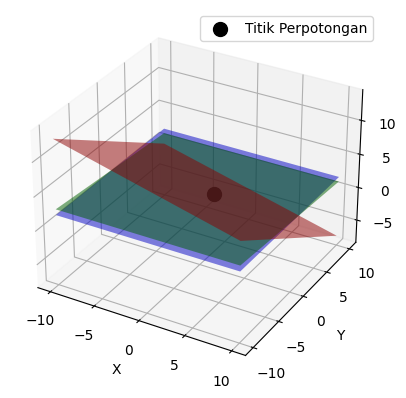

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Koefisien untuk masing-masing persamaan bidang
a1, b1, c1, r1 = 1, 2, 3, 9
a2, b2, c2, r2 = 0, 1, 13, 27
a3, b3, c3, r3 = 0, 0, 1, 2

# Buat data x, y
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)

# Buat grid x, y
X, Y = np.meshgrid(x, y)

# Hitung nilai z sesuai dengan persamaan bidang
Z1 = (r1 - a1*X - b1*Y) / c1
Z2 = (r2 - a2*X - b2*Y) / c2
Z3 = (r3 - a3*X - b3*Y) / c3

# Plot persamaan bidang dalam tiga dimensi
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot bidang
ax.plot_surface(X, Y, Z1, alpha=0.5, rstride=100, cstride=100, color='r')
ax.plot_surface(X, Y, Z2, alpha=0.5, rstride=100, cstride=100, color='g')
ax.plot_surface(X, Y, Z3, alpha=0.5, rstride=100, cstride=100, color='b')

# Titik perpotongan
A = np.array([[a1, b1, c1], [a2, b2, c2], [a3, b3, c3]])
B = np.array([r1, r2, r3])
intersect = np.linalg.solve(A, B)
ax.scatter(intersect[0], intersect[1], intersect[2], color='black', s=100, label='Titik Perpotongan')

# Label sumbu
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Tampilkan legenda
ax.legend()

# Tampilkan plot
plt.show()

#cara cek 2

In [ ]:
# Matriks augmented setelah eliminasi Gauss
augmented_matrix

# Jumlah baris dan kolom
num_rows, num_cols = augmented_matrix.shape

# Inisialisasi larik untuk solusi
solution = np.zeros(num_rows)

# Solusi mundur dari baris terakhir
for i in range(num_rows - 1, -1, -1):
    # Hitung nilai variabel
    solution[i] = augmented_matrix[i, num_cols - 1]
    for j in range(i + 1, num_rows):
        solution[i] -= augmented_matrix[i, j] * solution[j]
    solution[i] /= augmented_matrix[i, i]

# Cetak solusi sistem persamaan linear
print("Solusi sistem persamaan linear:")
for i in range(num_rows):
    print("x{} = {:.2f}".format(i + 1, solution[i]))


Solusi sistem persamaan linear:
x1 = 1.00
x2 = 1.00
x3 = 2.00


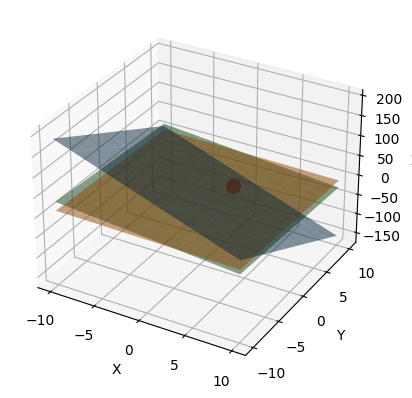

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Solusi dari sistem persamaan linear
solution = np.array([2, 3, 5])  # Contoh solusi, sesuaikan dengan hasil yang Anda dapatkan

# Fungsi untuk menghasilkan titik-titik pada bidang
def plane_points(normal_vector, d):
    x_range = np.linspace(-10, 10, 10)
    y_range = np.linspace(-10, 10, 10)
    x, y = np.meshgrid(x_range, y_range)
    z = (-normal_vector[0] * x - normal_vector[1] * y + d) / normal_vector[2]
    return x, y, z

# Persamaan bidang
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Persamaan 1: 8x1 + 9x2 + x3 = 19
x1, y1, z1 = plane_points([8, 9, 1], 19)
ax.plot_surface(x1, y1, z1, alpha=0.5)

# Persamaan 2: x1 + 2x2 + 3x3 = 9
x2, y2, z2 = plane_points([1, 2, 3], 9)
ax.plot_surface(x2, y2, z2, alpha=0.5)

# Persamaan 3: 2x1 + x2 + x3 = 5
x3, y3, z3 = plane_points([2, 1, 1], 5)
ax.plot_surface(x3, y3, z3, alpha=0.5)

# Tambahkan solusi sebagai titik pada bidang
ax.scatter(solution[0], solution[1], solution[2], color='red', s=100)

# Atur label sumbu
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Tampilkan plot
plt.show()


Solusi x: [2. 2. 1.]


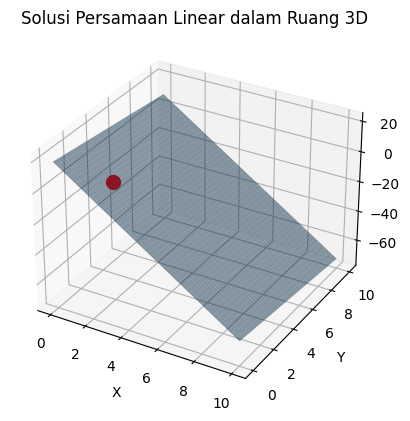

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Matriks koefisien dan vektor hasil
A = np.array([[8, 1, 1],
              [1, 2, 3],
              [2, 1, -1]])
b = np.array([19, 9, 5])

# Mencari solusi dengan np.linalg.solve
x = np.linalg.solve(A, b)

print("Solusi x:", x)

# Persamaan garis: z = ax + by + c
a, b, c, d = A[0, 0], A[0, 1], A[0, 2], b[0]

# Membuat data untuk garis
x_vals = np.linspace(0, 10, 50)
y_vals = np.linspace(0, 10, 50)
x_vals, y_vals = np.meshgrid(x_vals, y_vals)
z_vals = (-a*x_vals - b*y_vals + d) / c

# Membuat plot 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting permukaan
ax.plot_surface(x_vals, y_vals, z_vals, alpha=0.5)

# Menambahkan titik solusi
ax.scatter(x[0], x[1], x[2], color='red', s=100)

# Label sumbu
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('Solusi Persamaan Linear dalam Ruang 3D')
plt.show()


Solusi x: [2. 2. 1.]


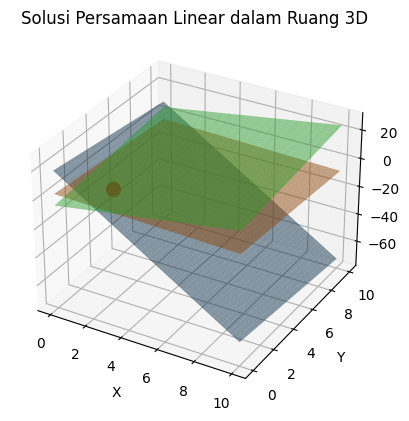

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Matriks koefisien dan vektor hasil
A = np.array([[8, 1, 1],
              [1, 2, 3],
              [2, 1, -1]])
b = np.array([19, 9, 5])

# Mencari solusi dengan np.linalg.solve
x = np.linalg.solve(A, b)

print("Solusi x:", x)

# Persamaan bidang: ax + by + cz + d = 0
a1, b1, c1, d1 = A[0, 0], A[0, 1], A[0, 2], -b[0]
a2, b2, c2, d2 = A[1, 0], A[1, 1], A[1, 2], -b[1]
a3, b3, c3, d3 = A[2, 0], A[2, 1], A[2, 2], -b[2]

# Membuat data untuk bidang
x_vals = np.linspace(0, 10, 50)
y_vals = np.linspace(0, 10, 50)
x_vals, y_vals = np.meshgrid(x_vals, y_vals)
z_vals1 = (-a1*x_vals - b1*y_vals - d1) / c1
z_vals2 = (-a2*x_vals - b2*y_vals - d2) / c2
z_vals3 = (-a3*x_vals - b3*y_vals - d3) / c3

# Membuat plot 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting bidang
ax.plot_surface(x_vals, y_vals, z_vals1, alpha=0.5)
ax.plot_surface(x_vals, y_vals, z_vals2, alpha=0.5)
ax.plot_surface(x_vals, y_vals, z_vals3, alpha=0.5)

# Menambahkan titik solusi
ax.scatter(x[0], x[1], x[2], color='red', s=100)

# Label sumbu
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('Solusi Persamaan Linear dalam Ruang 3D')
plt.show()
